# Leakage-proof ML pipelines — the hands-on half

The practical companion to **`leakage_slides.html`**. The deck explains *why*; this notebook
proves it with numbers you can watch appear.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 15–16 | install, sandbox, build two datasets |
| 1 · The lie | 18–19 | make a model score **0.70 on pure noise**, then fix it |
| 2 · Pipelines | 19–21 | `Pipeline`, `ColumnTransformer`, the fit/transform contract |
| 3 · Target leakage | 22–23 | a column that quietly contains the answer |
| 4 · Time and groups | 24–26 | `TimeSeriesSplit`, `GroupKFold`, duplicates |
| 5 · Advanced | 30–36 | nested CV, safe target encoding, thresholds |

**Data leakage** is when information reaches your model that it would not have at prediction
time. It does not crash. It does not warn you. It just makes your offline score better than
reality, and you find out after you ship.

Everything runs in a throwaway `leakage_demo/` folder; the last cell deletes it.

## Step 0.1 · Install

Only scikit-learn, pandas and matplotlib.

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib

# Housekeeping, not part of the lesson: pandas prints "Pandas requires version ... of
# numexpr / bottleneck" when those are a version behind. That is about this machine, and
# joblib reprints it from every worker process, which buries the results.
import os, warnings
warnings.filterwarnings("ignore", message="Pandas requires version")
os.environ["PYTHONWARNINGS"] = "ignore:Pandas requires version"   # workers inherit this



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


`%matplotlib inline` is deliberate: with `matplotlib.use("Agg")` the charts render to files and
never appear in the notebook, which is a confusing half-hour if you have not hit it before.

In [2]:
%matplotlib inline
# ^ inline, NOT matplotlib.use("Agg") -- Agg renders to file and your charts silently vanish.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.7.2


## Step 0.2 · A sandbox to work in

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "leakage_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/01-leakage-proof-pipeline/leakage_demo


## Step 0.3 · Two datasets

**`noise`** — 200 rows, 2,000 columns of pure random numbers, and a coin-flip label. There is
**no signal whatsoever**. An honest model cannot beat 50%. We will make it score 70%.

**`customers`** — a realistic tabular set with numbers, categories, missing values, a
timestamp and a customer id. We use it for the pipeline work.

In [4]:
rng = np.random.default_rng(0)

# ---------------------------------------------------------------- dataset 1
# Pure noise: 2000 random columns, and a label that is a coin flip.
# There is NO signal here. Any accuracy above 0.50 is self-deception.
n_rows, n_cols = 200, 2000
X_noise = pd.DataFrame(rng.normal(size=(n_rows, n_cols)),
                       columns=[f"f{i}" for i in range(n_cols)])
y_noise = pd.Series(rng.integers(0, 2, n_rows), name="y")

print(f"noise dataset: {n_rows} rows x {n_cols} random columns, "
      f"label balance {y_noise.mean():.2f}")


# ---------------------------------------------------------------- dataset 2
# Something that looks like a real customer table.
m = 3000
cust = pd.DataFrame({
    "customer_id":    rng.integers(1, 600, m),      # repeats -> these are groups
    "signup_day":     rng.integers(0, 365, m),      # gives us a time order
    "tenure_months":  rng.integers(1, 72, m),
    "monthly_charge": rng.normal(65, 20, m).round(2),
    "support_calls":  rng.poisson(1.2, m),
    "plan":           rng.choice(["basic", "plus", "pro"], m, p=[.5, .3, .2]),
    "region":         rng.choice(["north", "south", "east", "west"], m),
})

# real data has holes
cust.loc[rng.random(m) < 0.08, "monthly_charge"] = np.nan

# churn depends on tenure, charge and support calls, plus noise
risk = (-0.04 * cust.tenure_months
        + 0.03 * cust.monthly_charge.fillna(65)
        + 0.55 * cust.support_calls
        + rng.normal(0, 0.8, m))
cust["churn"] = (risk > risk.mean()).astype(int)

print(f"customer table: {m} rows, {cust.isna().sum().sum()} missing values, "
      f"churn rate {cust.churn.mean():.2f}")
cust.head()


noise dataset: 200 rows x 2000 random columns, label balance 0.49
customer table: 3000 rows, 228 missing values, churn rate 0.49


,customer_id,signup_day,tenure_months,monthly_charge,support_calls,plan,region,churn
0,456,315,33,61.25,2,plus,south,0
1,519,21,5,70.36,0,plus,north,1
2,19,334,43,46.18,1,basic,east,0
3,287,350,63,71.55,0,basic,north,0
4,594,73,64,58.75,1,basic,east,0


---
# Part 1 — The lie   ·   deck slides 18–19

## Step 1.1 · Scoring 70% on data with no signal

Here is the single most common leak, and it looks completely reasonable:

1. look at the whole dataset, keep the 20 features most correlated with the label
2. cross-validate a model on those 20 features
3. report the score

Step 1 saw the labels of every row — including the rows used for testing in step 2. The
features were *chosen because* they happen to match those labels.

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# ---- THE LEAK: choose features using the whole dataset, then cross-validate ----
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)     # <-- sees every label
X_selected = X_noise.iloc[:, selector.get_support()]

leaked = cross_val_score(LogisticRegression(max_iter=1000),
                         X_selected, y_noise, cv=cv).mean()
print(f"LEAKED  cv accuracy: {leaked:.3f}")

LEAKED  cv accuracy: 0.765


That number is nonsense — the data is random. Now do exactly the same thing with the feature
selection **inside** the pipeline, so it happens separately on each training fold and never
sees the fold being tested.

In [ ]:
from sklearn.pipeline import Pipeline

honest_pipe = Pipeline([
    ("select", SelectKBest(f_classif, k=20)),        # refitted on each training fold only
    ("model",  LogisticRegression(max_iter=1000)),
])
honest = cross_val_score(honest_pipe, X_noise, y_noise, cv=cv).mean()

print(f"LEAKED  cv accuracy: {leaked:.3f}")
print(f"HONEST  cv accuracy: {honest:.3f}")
print(f"GAP:               {leaked - honest:+.3f}   <- pure self-deception")
print()
print("Reality check: the labels are coin flips, so the truth is 0.500.")

# if this ever stops being true, the demo is broken and should shout about it
assert leaked - honest > 0.10, "the leak should inflate the score substantially"

LEAKED  cv accuracy: 0.765
HONEST  cv accuracy: 0.520
GAP:               +0.245   <- pure self-deception

Reality check: the labels are coin flips, so the truth is 0.500.


The two scores side by side. The gap **is** the leak — nothing about the data changed between
them, only whether the preprocessing was allowed to see the test rows.

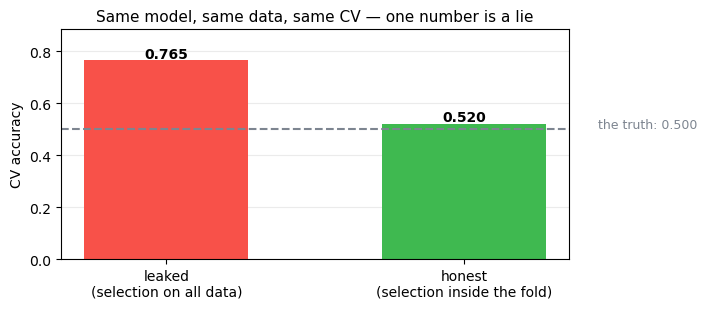

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
bars = ax.bar(["leaked\n(selection on all data)", "honest\n(selection inside the fold)"],
              [leaked, honest], color=["#f85149", "#3fb950"], width=.55)
ax.axhline(0.5, ls="--", color="#7d8590")
ax.text(1.45, 0.505, "the truth: 0.500", color="#7d8590", fontsize=9)
for b, v in zip(bars, [leaked, honest]):
    ax.text(b.get_x() + b.get_width()/2, v + .01, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, max(leaked, honest) + .12); ax.set_ylabel("CV accuracy")
ax.set_title("Same model, same data, same CV — one number is a lie", fontsize=11)
ax.grid(axis="y", alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

> **The rule that prevents this:** every step that *learns anything from the data* — a scaler's
> mean, an imputer's median, a selector's choice of columns, an encoder's category list — must
> be fitted **inside** the cross-validation loop, on the training fold only.
>
> `Pipeline` exists to make that automatic. That is its whole job.

---
# Part 2 — Pipelines that cannot leak   ·   deck slides 19–21

## Step 2.1 · Not every leak is the same size

Feature selection was the dramatic case: **+0.245**. Now measure the everyday case — scaling and
imputing before the split — and compare. The answer is not what most tutorials imply, and knowing
which leaks actually cost you something is more useful than a blanket warning.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

num_cols = ["tenure_months", "monthly_charge", "support_calls"]
X, y = cust[num_cols], cust.churn


def leaky_score(seed):
    """Fill and scale using EVERY row -- including the ones we are about to test on."""
    filled = SimpleImputer(strategy="mean").fit_transform(X)
    scaled = StandardScaler().fit_transform(filled)
    X_tr, X_te, y_tr, y_te = train_test_split(scaled, y, test_size=.3,
                                              random_state=seed, stratify=y)
    model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    return accuracy_score(y_te, model.predict(X_te))


def honest_score(seed):
    """Split first, then learn the statistics on the training rows only."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.3,
                                              random_state=seed, stratify=y)
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="mean")),
        ("scale",  StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000)),
    ]).fit(X_tr, y_tr)
    return accuracy_score(y_te, pipe.predict(X_te))


# one split is noise, so measure the gap over twenty of them
gaps = [leaky_score(s) - honest_score(s) for s in range(20)]

print(f"leaky  accuracy (first split): {leaky_score(0):.4f}")
print(f"honest accuracy (first split): {honest_score(0):.4f}")
print()
print(f"average gap over 20 splits: {np.mean(gaps):+.4f}")
print(f"largest gap seen:           {max(gaps):+.4f}")
print(f"the leak helped in {sum(g > 0 for g in gaps)} of 20 splits")


leaky  accuracy (first split): 0.8100
honest accuracy (first split): 0.8100

average gap over 20 splits: +0.0001
largest gap seen:           +0.0011
the leak helped in 2 of 20 splits


### Read that carefully: the gap is roughly **zero**

Scaling and imputing leak the *global mean and standard deviation* — three numbers, computed from
rows that mostly overlap with the training set anyway. Logistic regression barely notices.

Feature selection leaked **+0.245** because what escaped was far more valuable: *which of 2000
columns happen to correlate with the labels*, chosen with the test labels in view.

| Leaky step | What escapes | Cost on this data |
|---|---|---|
| `StandardScaler`, `SimpleImputer` | a mean and a standard deviation | ~0.000 |
| `SelectKBest`, any feature selection | which columns look predictive | **+0.245** |
| a column recorded after the outcome | the answer itself | **+0.106** (Part 3) |
| the same customer in train and test | that customer's behaviour | **+0.055** (Part 4) |

**So why still put the scaler in a Pipeline?** Because it costs one line, and because you cannot
tell in advance which kind you have. The habit is free; auditing every step for how much it leaks
is not.

> Most tutorials show the scaler example and imply a big number. On this data there is not one.
> Being specific about which leaks are expensive beats a warning that treats them all alike.

## Step 2.2 · `ColumnTransformer` — different treatment per column type

Real tables mix numbers and categories, and each needs different preprocessing. The point is that
all of it lives inside **one estimator** with one `fit`, so it cannot see the test set.


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric     = ["tenure_months", "monthly_charge", "support_calls", "signup_day"]
categorical = ["plan", "region"]
features    = numeric + categorical


def make_model(numeric_cols=numeric, categorical_cols=categorical):
    """A leak-proof model: fill + scale the numbers, one-hot the categories, then fit.

    Every demo below calls this instead of rebuilding the same nested object, so the
    only thing that changes between demos is the list of columns.
    """
    numbers = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ])
    prep = ColumnTransformer([
        ("num", numbers, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    return Pipeline([
        ("prep",  prep),
        ("model", RandomForestClassifier(n_estimators=200, random_state=0)),
    ])


def auc(model, data, columns, cv, groups=None):
    """Mean ROC AUC across the folds. Just to keep the demos to one line each."""
    scores = cross_val_score(model, data[columns], data.churn, cv=cv,
                             groups=groups, scoring="roc_auc")
    return scores.mean()


clf = make_model()
scores = cross_val_score(clf, cust[features], cust.churn, cv=cv, scoring="roc_auc")
print(f"honest 5-fold ROC AUC: {scores.mean():.4f}  (+/- {scores.std():.4f})")
print()
print("handle_unknown='ignore' matters: a category that only appears in the test fold")
print("must not crash prediction -- in production it certainly will appear.")


honest 5-fold ROC AUC: 0.8734  (+/- 0.0123)

handle_unknown='ignore' matters: a category that only appears in the test fold
must not crash prediction -- in production it certainly will appear.


### The fit/transform contract, in one line each

| Call | Who may use it | What it does |
|---|---|---|
| `fit(X_train)` | training data **only** | learns the statistics (means, categories, columns) |
| `transform(X)` | anything | applies what was already learned |
| `fit_transform(X_train)` | training data **only** | both, in one step |

Calling `fit` or `fit_transform` on test data — or on the full dataset before splitting — is
the bug. There is no other way to leak through preprocessing.

In [10]:
# Proof that the pipeline learned only from the training fold.
X_tr, X_te, y_tr, y_te = train_test_split(cust[features], cust.churn,
                                          test_size=.3, random_state=0,
                                          stratify=cust.churn)
fitted = make_model().fit(X_tr, y_tr)

# dig out the imputer the pipeline fitted, and ask what median it learned
prep    = fitted.named_steps["prep"]
imputer = prep.named_transformers_["num"].named_steps["impute"]
learned = imputer.statistics_[numeric.index("monthly_charge")]

print(f"median learned from the training fold: {learned:.4f}")
print(f"median of the WHOLE dataset:           {cust.monthly_charge.median():.4f}")
print()
print("Different numbers -- which is the point. The pipeline never saw the test rows.")


median learned from the training fold: 63.5500
median of the WHOLE dataset:           63.8750

Different numbers -- which is the point. The pipeline never saw the test rows.


---
# Part 3 — Target leakage   ·   deck slide 22–23

Preprocessing leakage is a mistake in *how* you fit. Target leakage is a mistake in *what
columns exist*: a feature that is a consequence of the outcome, or recorded after it.

Classic real examples: `account_closed_date` when predicting churn, `total_paid` when
predicting default, `discharge_code` when predicting readmission. Each is unknowable at
prediction time.

In [11]:
# A column a data engineer might hand you: "did we phone them to keep them?"
# It is recorded AFTER the customer decided to leave, so it half-contains the answer.
leaky_cust = cust.copy()
called = np.where(leaky_cust.churn == 1,
                  rng.random(len(leaky_cust)) < 0.92,     # we call most leavers
                  rng.random(len(leaky_cust)) < 0.06)     # and few stayers
leaky_cust["retention_call_made"] = called.astype(int)

# The only difference between the two models is whether that column is listed.
with_leak = auc(make_model(numeric + ["retention_call_made"]),
                leaky_cust, features + ["retention_call_made"], cv)
without   = auc(make_model(), leaky_cust, features, cv)

print(f"with 'retention_call_made':  ROC AUC {with_leak:.4f}")
print(f"without it:                  ROC AUC {without:.4f}")
print(f"suspiciously good:           {with_leak - without:+.4f}")

assert with_leak - without > 0.05, "the target-leak demo must show a large jump"


with 'retention_call_made':  ROC AUC 0.9797
without it:                  ROC AUC 0.8734
suspiciously good:           +0.1063


No pipeline can save you here — the leak is in the column, not the fitting. Two habits catch it:

1. **Be suspicious of a great score.** 0.99 usually means a bug, not a breakthrough.
2. **Ask of every feature: would this value exist, with this value, at the moment I need to
   predict?** A retention call is *made because* the customer was churning. It is an effect,
   not a cause.

`permutation_importance` is a good tripwire — one feature dominating everything is worth a look.

In [12]:
from sklearn.inspection import permutation_importance

leak_features = features + ["retention_call_made"]
fitted_leak = make_model(numeric + ["retention_call_made"]).fit(
    leaky_cust[leak_features], leaky_cust.churn)

# shuffle each column in turn and see how much the score falls
imp = permutation_importance(fitted_leak, leaky_cust[leak_features], leaky_cust.churn,
                             n_repeats=3, random_state=0, scoring="roc_auc")

for i in np.argsort(imp.importances_mean)[::-1][:4]:
    print(f"  {leak_features[i]:22} {imp.importances_mean[i]:+.4f}")
print()
print("One feature carrying the whole model is a smell, not a win.")


  retention_call_made    +0.2333
  tenure_months          +0.0245
  monthly_charge         +0.0093
  support_calls          +0.0075

One feature carrying the whole model is a smell, not a win.


---
# Part 4 — Time and groups   ·   deck slides 24–26

`KFold` shuffles rows. That is wrong in two very common situations.

## Step 4.1 · Time: never train on the future

If rows have an order in time, a shuffled split lets the model learn from next month to
predict last month. Use `TimeSeriesSplit`, which only ever trains on the past.

In [13]:
from sklearn.model_selection import TimeSeriesSplit

ordered = cust.sort_values("signup_day").reset_index(drop=True)

shuffled = auc(clf, ordered, features, StratifiedKFold(5, shuffle=True, random_state=0))
temporal = auc(clf, ordered, features, TimeSeriesSplit(n_splits=5))

print(f"shuffled  KFold  ROC AUC: {shuffled:.4f}   <- trains on the future")
print(f"TimeSeriesSplit  ROC AUC: {temporal:.4f}   <- past only, the honest estimate")
print()
print("On this synthetic set the gap is small because churn does not drift over time.")
print("On real data it is often large, and always in the same direction.")


shuffled  KFold  ROC AUC: 0.8707   <- trains on the future
TimeSeriesSplit  ROC AUC: 0.8563   <- past only, the honest estimate

On this synthetic set the gap is small because churn does not drift over time.
On real data it is often large, and always in the same direction.


## Step 4.2 · Groups: the same customer in train and test

`customer_id` repeats in this dataset. A shuffled split puts some of a customer's rows in
train and others in test, so the model can memorise the customer instead of learning the
pattern. `GroupKFold` keeps every group whole on one side of the split.

In [14]:
from sklearn.model_selection import GroupKFold

# Give each customer a hidden tendency to churn that is NOT in any column.
# A model can only capture it by memorising the customer id itself.
dup = cust.copy()
tendency = pd.Series(rng.normal(0, 3, dup.customer_id.max() + 1))
dup["churn"] = ((dup.customer_id.map(tendency) + rng.normal(0, 1, len(dup))) > 0).astype(int)

# customer_id is now a feature the model can memorise -- but only for customers
# it has already seen. That is exactly what group leakage looks like.
model    = make_model(numeric + ["customer_id"])
group_ft = features + ["customer_id"]

shuffled = auc(model, dup, group_ft, StratifiedKFold(5, shuffle=True, random_state=0))
grouped  = auc(model, dup, group_ft, GroupKFold(n_splits=5), groups=dup.customer_id)

print(f"rows per customer: {len(dup) / dup.customer_id.nunique():.1f}")
print(f"shuffled KFold  ROC AUC: {shuffled:.4f}   <- same customers on both sides")
print(f"GroupKFold      ROC AUC: {grouped:.4f}   <- customers it has never seen")
print(f"optimism from group leakage: {shuffled - grouped:+.4f}")

assert shuffled - grouped > 0.05, "the group-leak demo must show large optimism"


rows per customer: 5.1
shuffled KFold  ROC AUC: 0.5727   <- same customers on both sides
GroupKFold      ROC AUC: 0.5183   <- customers it has never seen
optimism from group leakage: +0.0545


## Step 4.3 · Duplicates

Exact or near-duplicate rows do the same damage as group leakage, silently. Check before you
split — it costs one line.

In [15]:
d = pd.concat([cust, cust.sample(300, random_state=1)], ignore_index=True)   # 300 dupes
print("rows:", len(d), " exact duplicates:", int(d.duplicated().sum()))
print("after dropping:", len(d.drop_duplicates()))
print("\nDeduplicate BEFORE splitting, or the same row lands in train and test.")

rows: 3300  exact duplicates: 300
after dropping: 3000

Deduplicate BEFORE splitting, or the same row lands in train and test.


---
# Part 5 — Advanced   ·   deck slides 30–36

## Step 5.1 · Nested cross-validation

If you tune hyperparameters with CV and then report that same CV score, the score is
optimistic — you chose the settings that happened to suit those folds. Nested CV keeps an
outer loop that the tuning never sees.

In [16]:
from sklearn.model_selection import GridSearchCV

# A small sample and a wide grid: exactly the conditions where tuning fools you.
small = cust.sample(300, random_state=0)
grid_values = {"model__max_depth":        [1, 2, 3, 5, 8, None],
               "model__min_samples_leaf": [1, 5, 20]}

search = GridSearchCV(make_model(), grid_values, scoring="roc_auc", n_jobs=-1,
                      cv=StratifiedKFold(3, shuffle=True, random_state=0))

# flat: tune, then report that same best score
flat = search.fit(small[features], small.churn).best_score_

# nested: the whole search runs inside each outer fold, and never sees it
nested = auc(search, small, features, StratifiedKFold(3, shuffle=True, random_state=1))

print(f"flat   (tuned and reported on the same folds): {flat:.4f}")
print(f"nested (tuning never saw the outer fold):      {nested:.4f}")
print(f"optimism from tuning: {flat - nested:+.4f}")
print()
print(f"best params: {search.best_params_}")
print()
print("18 combinations x 3 folds on 300 rows: some combination fits the folds by luck.")


flat   (tuned and reported on the same folds): 0.8178
nested (tuning never saw the outer fold):      0.8061
optimism from tuning: +0.0117

best params: {'model__max_depth': 8, 'model__min_samples_leaf': 5}

18 combinations x 3 folds on 300 rows: some combination fits the folds by luck.


## Step 5.2 · Target encoding, done safely

Replacing a category with the mean of the target for that category is powerful and leaks
badly if you compute it on the whole dataset. sklearn's `TargetEncoder` fits **inside** the
pipeline and uses internal cross-fitting.

In [17]:
try:
    from sklearn.preprocessing import TargetEncoder          # scikit-learn >= 1.3

    safe = Pipeline([
        ("prep", ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), numeric),
            ("cat", TargetEncoder(random_state=0),    categorical),
        ])),
        ("model", RandomForestClassifier(n_estimators=200, random_state=0)),
    ])
    score = auc(safe, cust, features, cv)

    print(f"TargetEncoder inside the pipeline: ROC AUC {score:.4f}")
    print("It cross-fits internally, so a row never sees its own target in its encoding.")

except ImportError:
    print("TargetEncoder needs scikit-learn >= 1.3; use category_encoders inside a Pipeline.")


TargetEncoder inside the pipeline: ROC AUC 0.8758
It cross-fits internally, so a row never sees its own target in its encoding.


## Step 5.3 · Choose the threshold on validation, not on test

A classifier outputs probabilities; the decision threshold is a *hyperparameter*. Pick it on
data the final score never touches, or you have leaked again — this time through a number you
tuned by eye.

In [18]:
from sklearn.metrics import f1_score, roc_auc_score

# three-way split: train, validation (to choose the threshold), test (to report)
X_tr, X_rest, y_tr, y_rest = train_test_split(cust[features], cust.churn, test_size=.4,
                                              random_state=0, stratify=cust.churn)
X_val, X_te, y_val, y_te = train_test_split(X_rest, y_rest, test_size=.5,
                                            random_state=0, stratify=y_rest)
print(f"train {len(X_tr)}  ·  validation {len(X_val)}  ·  test {len(X_te)}")

model = make_model().fit(X_tr, y_tr)

# choose the cut-off on VALIDATION -- choosing it on the test set is leakage
val_proba  = model.predict_proba(X_val)[:, 1]
candidates = np.linspace(.2, .8, 61)
f1_per_threshold = [f1_score(y_val, val_proba > t) for t in candidates]
best_t = float(candidates[np.argmax(f1_per_threshold)])

test_proba = model.predict_proba(X_te)[:, 1]
print()
print(f"threshold chosen on validation:  {best_t:.3f}")
print(f"test F1 at 0.5:                  {f1_score(y_te, test_proba > 0.5):.4f}")
print(f"test F1 at the chosen threshold: {f1_score(y_te, test_proba > best_t):.4f}")
print(f"test ROC AUC (threshold-free):   {roc_auc_score(y_te, test_proba):.4f}")


train 1800  ·  validation 600  ·  test 600

threshold chosen on validation:  0.420
test F1 at 0.5:                  0.7666
test F1 at the chosen threshold: 0.7672
test ROC AUC (threshold-free):   0.8636


## Step 5.4 · Ship the pipeline, not the model

The fitted `Pipeline` contains the imputer's medians, the scaler's means, the encoder's
categories and the model. Persist the whole object, and serving cannot drift from training.

In [19]:
import joblib
joblib.dump(model, "churn_pipeline.joblib")

loaded = joblib.load("churn_pipeline.joblib")
raw = cust[features].iloc[:3]              # untouched raw rows, missing values and all
print("raw input goes straight in:")
print(raw.to_string(index=False))
print("\npredictions:", loaded.predict(raw))
print("\nNo separate preprocessing code to keep in sync. That is the deployment win.")

raw input goes straight in:
 tenure_months  monthly_charge  support_calls  signup_day  plan region
            33           61.25              2         315  plus  south
             5           70.36              0          21  plus  north
            43           46.18              1         334 basic   east

predictions: [1 1 0]

No separate preprocessing code to keep in sync. That is the deployment win.


---
# The audit — five questions before you trust a score

| # | Question | Fix if the answer is bad |
|---|---|---|
| 1 | Is every fitted step inside a `Pipeline`? | wrap it — `Pipeline`, `ColumnTransformer` |
| 2 | Would each feature exist, with this value, at prediction time? | drop the feature |
| 3 | Do rows have an order in time? | `TimeSeriesSplit` |
| 4 | Do rows repeat an entity — customer, patient, device? | `GroupKFold` with that id |
| 5 | Were hyperparameters or thresholds tuned on the reported split? | nested CV, or a held-back test set |

> **Reference:** deck slides 30–36 cover custom transformers, `set_output(transform="pandas")`,
> `get_feature_names_out`, imbalanced data with `imblearn` inside a pipeline, and calibration.

## Recap

| You wanted to… | Do this |
|---|---|
| stop preprocessing leaking | put every fitted step in a `Pipeline` |
| treat columns differently | `ColumnTransformer` |
| survive unseen categories | `OneHotEncoder(handle_unknown="ignore")` |
| respect time | `TimeSeriesSplit` |
| respect entities | `GroupKFold(groups=...)` |
| tune without fooling yourself | nested CV |
| encode categories with the target | `TargetEncoder` inside the pipeline |
| pick a threshold | on a validation split, never on test |
| deploy | `joblib.dump(fitted_pipeline)` |

## What to do at work tomorrow

1. Take your current notebook and count the `fit_transform` calls that happen before the split.
2. Wrap them in a `Pipeline`. Re-run. **Write down how much the score drops** — that number is
   how wrong you were.
3. Check for repeated entities and for time order. Switch the splitter if either applies.
4. Only then tune.

## Cleanup

Everything above happened in the sandbox. This removes it.

In [20]:
import shutil, os
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

sandbox removed
